In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import pandas as pd
from scipy import interpolate

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

# Constants

In [3]:
# List of atmoic numbers
A_dict = {'H' : 1.00797 ,
'He' : 4.00260 ,
'Li' : 6.941 ,
'Be' : 9.01218 ,
'B' : 10.81 ,
'C' : 12.011 ,
'N' : 14.0067 ,
'O' : 15.994 ,
'F' : 18.9994 ,
'Ne' : 20.179 ,
'Na' : 22.98977 ,
'Mg' : 24.305 ,
'Al' : 26.98154 ,
'Si' : 28.0855 ,
'P' : 30.97376 ,
'S' : 32.06 ,
'Cl' : 35.453 ,
'A' : 39.948 ,
'K' : 39.0983 ,
'Ca' : 40.08 ,
'Sc' : 44.9559 ,
'Ti' : 47.90 ,
'V' : 50.9415 ,
'Te' : 51.996 ,
'Mn' : 54.9380 ,
'Fe' : 55.847 ,
'Co' : 58.70 ,
'Ni' : 58.9332 ,
'Cu' : 63.546 ,
'Zn' : 65.38,
}

In [4]:
# Significance levels
# Sigma values taken from Gehrels 1986
cdf_1sig = 0.8413
cdf_2sig = 0.9772
cdf_3sig = 0.9987

In [5]:
# Boltzmann constant, adjusted to use km instead of m
k_B = 1.380649e-29
# Mass of hydrogen atom
amu = 1.66054e-27

# Functions

In [6]:
def gen_b(logT, b_NT, A):
    
    return np.sqrt((2*k_B*10**logT/(A*amu)) + b_NT**2)

In [7]:
def log_prior(params):

    # Grid parameters being varied
    logT, b_NT = params
    
    # Avoid edges?
    if 4<logT<6 and 0<b_NT<50:
        return np.log(10**logT)
    return -np.inf

In [8]:
def log_likelihood(params, b_list):
    
    logT, b_NT = params

    #print(logT, b_NT)
    
    ll = 0
    
    for i in range(len(b_list)):
        
        ybar = gen_b(logT, b_NT, A_dict[b_list[i][1]])
        y = b_list[i][2]
        dy = b_list[i][3]
        
        ll += -.5*(y-ybar)**2/dy**2
            
    return ll

In [9]:
def log_probability(params, b_list):
        
    lp = log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, b_list)

In [10]:
gen_b(4, 0, A_dict['H'])

12.844232700646511

In [11]:
gen_b(4, 0, A_dict['C'])

3.7208519053703197

In [12]:
gen_b(4, 0, A_dict['N'])

3.445593622658098

In [13]:
gen_b(4, 0, A_dict['O'])

3.2244334848939453

In [14]:
gen_b(4, 0, A_dict['Si'])

2.433273287255247

# z=0.67

In [33]:
b_list = [[['HI', 'H', 36, 2],
          ['CIII', 'C', 31, 2],
          ['CIV', 'C', 32, 5],
          ['OIII', 'O', 33, 2],
          ['OIV', 'O', 30, 2],
          ['OVI', 'O', 31, 3]
          ]]

In [49]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [50]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [51]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:19<00:00, 256.63it/s]


State([[ 4.03171094 32.29786112]
 [ 4.42412498 31.02670347]
 [ 4.39669831 30.83930988]
 [ 4.37897616 28.50987124]
 [ 4.4478429  30.66504543]
 [ 4.50029097 32.21574151]
 [ 4.39509601 31.23608819]
 [ 4.37022635 30.33176218]
 [ 4.59025443 29.57117237]
 [ 4.42466882 30.04430631]
 [ 4.4175763  30.68505153]
 [ 4.10919286 32.56597469]
 [ 4.66441063 29.94652536]
 [ 4.07311657 29.03129334]
 [ 4.46880387 31.67623049]
 [ 4.35978762 30.64690894]
 [ 4.56209672 28.89954294]
 [ 4.1578524  32.6466887 ]
 [ 4.26181689 29.64207662]
 [ 4.23779614 32.81120625]
 [ 4.02650108 30.82720993]
 [ 4.68813777 28.57466318]
 [ 4.15642485 30.71806146]
 [ 4.50357958 30.23955117]
 [ 4.45388017 29.66590847]
 [ 4.22545829 31.15773862]
 [ 4.57491943 29.71174057]
 [ 4.25738079 32.88901474]
 [ 4.5141939  28.03232155]
 [ 4.1340861  31.19713105]
 [ 4.10309386 28.96375545]
 [ 4.38858861 30.19810531]
 [ 4.30579166 32.35359734]
 [ 4.50128543 32.15287842]
 [ 4.38547522 30.20298831]
 [ 4.46031284 30.11092792]
 [ 4.36759057 29.49478

In [54]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

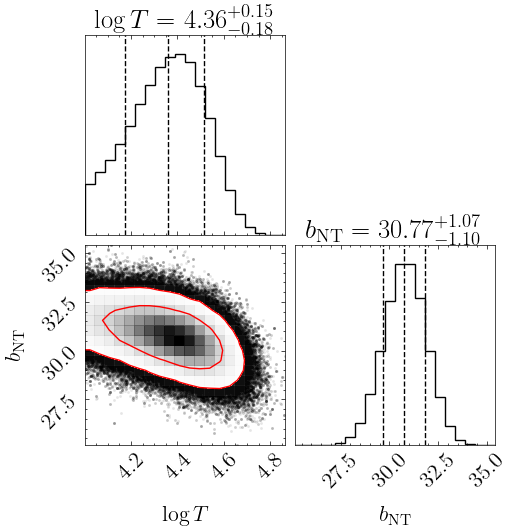

In [55]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [56]:
pdf, edges = np.histogram(flat_samples['logT'], bins=100)
centers = .5*(edges[1:]+edges[:-1])
cdf = np.cumsum(pdf)/np.sum(pdf)
ppf = interpolate.interp1d(x=cdf, y=10**centers)

Text(0, 0.5, 'CDF')

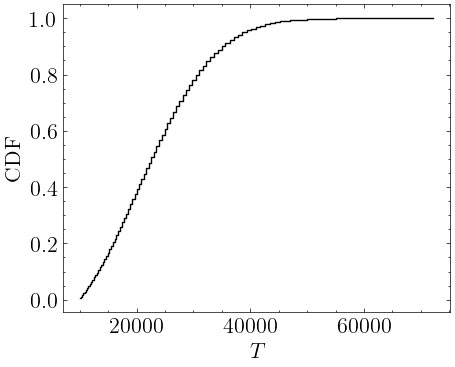

In [57]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.step(10**centers, cdf, where='mid')
ax.set_xlabel(r'$T$')
ax.set_ylabel('CDF')

In [59]:
np.log10(ppf(cdf_3sig))

4.7332913369164595

Predicted linewidths

In [60]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

31.298833223381575

In [61]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

31.22309119542496

In [62]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

31.167323011709158

In [63]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

31.085867465066574

In [64]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

31.032760141653693

In [65]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

31.00687378495347

In [66]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

30.997735659700943

In [67]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

30.969886930915596

In [68]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

30.88628147430108

# z=0.72

In [69]:
b_list = [[['HI', 'H', 25.6, 0.4],
          ['CIII', 'C', 15, 4],
          ['OIII', 'O', 12, 2]]]

In [70]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [71]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [72]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:13<00:00, 378.65it/s]


State([[ 4.5384403   8.09929585]
 [ 4.47312911 12.56506458]
 [ 4.51935019  9.9915456 ]
 [ 4.43163142 15.65060414]
 [ 4.52375086  9.37540148]
 [ 4.54954478  6.62458899]
 [ 4.52685679 10.13970275]
 [ 4.42873199 14.08212653]
 [ 4.50605638 12.29829318]
 [ 4.50825934 10.95642096]
 [ 4.52653629 10.0437353 ]
 [ 4.43088461 14.06331714]
 [ 4.52991303 10.05491318]
 [ 4.5366154   8.2728032 ]
 [ 4.57220497  8.25733952]
 [ 4.47898707 12.46445221]
 [ 4.57009848  8.66609242]
 [ 4.50306259 11.53717785]
 [ 4.36597978 15.86877089]
 [ 4.56793488  9.68422604]
 [ 4.45187513 13.86462879]
 [ 4.56351901  5.3446461 ]
 [ 4.59466794  3.46409942]
 [ 4.53785633  9.65510504]
 [ 4.55211141  8.05027689]
 [ 4.49100075 11.93868292]
 [ 4.54138785 10.3322841 ]
 [ 4.54959999  9.2107803 ]
 [ 4.42833962 14.57471485]
 [ 4.51295023 12.04145711]
 [ 4.59385652  7.83400509]
 [ 4.46092935 12.78548227]
 [ 4.5263072  12.37414796]
 [ 4.48133168 13.77105522]
 [ 4.49751563 10.66109777]
 [ 4.53237196  9.36835803]
 [ 4.53007861 10.24665

In [73]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

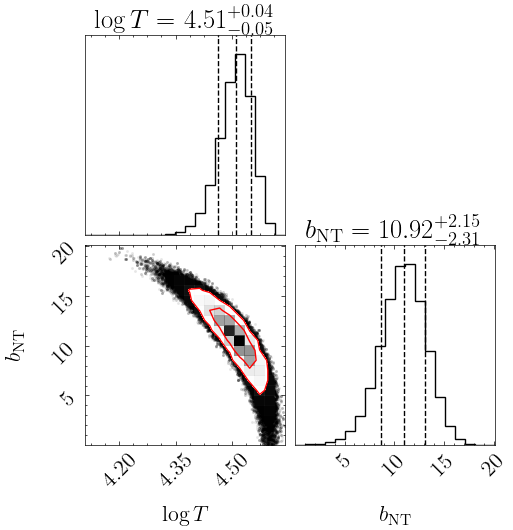

In [74]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Predicted linewidths

In [75]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

12.821218751413966

In [76]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

12.567972555170432

In [77]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

12.375375197197565

In [78]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

12.088713599866455

In [79]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

11.898696060874855

In [80]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

11.805498059645785

In [81]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

11.77212289470581

In [82]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

11.670068905881259

In [83]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

11.358898777000608

# z=1.04, c1

In [84]:
b_list = [[['HI', 'H', 18, 1],
          ['CIV', 'C', 6.7, 0.2]]]

In [85]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [86]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [87]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:10<00:00, 476.84it/s]


State([[4.18091244 4.56441102]
 [4.33055208 4.02339436]
 [4.16659069 4.89738139]
 [4.12256755 5.11586722]
 [4.29723138 4.20163272]
 [4.36245639 3.74048823]
 [4.28077757 4.28941206]
 [4.37740839 3.23076397]
 [4.35016638 3.94251361]
 [4.25054426 4.29697151]
 [4.31921727 4.01500037]
 [4.16058124 5.05755036]
 [4.36294417 3.12674852]
 [4.30576873 4.67772728]
 [4.25801759 4.47030199]
 [4.33785091 3.81701908]
 [4.33800995 3.34969318]
 [4.28199163 4.44614167]
 [4.22021884 4.86534563]
 [4.18329478 5.3235482 ]
 [4.2063496  4.66418965]
 [4.2634107  3.6721327 ]
 [4.20404184 4.9356933 ]
 [4.28391809 3.83010547]
 [4.28333273 3.81315367]
 [4.35327286 3.46552484]
 [4.27807335 4.50924441]
 [4.29716988 4.23625468]
 [4.19208694 4.73015593]
 [4.29269465 3.61320417]
 [4.40490057 2.76718367]
 [4.34689036 3.74538247]
 [4.16234249 4.96446067]
 [4.14431418 5.31743701]
 [4.26147352 4.40566564]
 [4.32322387 4.02136069]
 [4.2908126  4.17602569]
 [4.29041468 4.29267727]
 [4.18906708 4.82986314]
 [4.2388577  4.5103

In [88]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

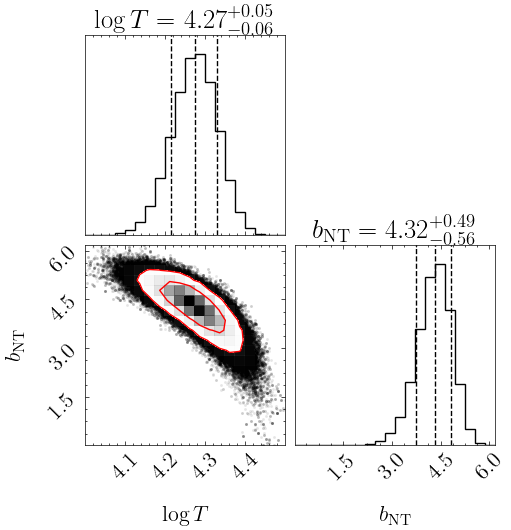

In [89]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Predicted linewidths

In [90]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['He']))

9.847679206539937

In [91]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

6.689231567860655

In [92]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

6.404684782634343

In [93]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

6.1833214490905455

In [94]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

5.845424386274184

In [95]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

5.615392942377073

In [96]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

5.500406068541091

In [97]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

5.458758849277018

In [98]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

5.330659266057261

In [99]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

4.925285821458428

# z=1.04, c2

In [100]:
b_list = [[['HI', 'H', 11, 2],
          ['CIV', 'C', 6.2, 0.4]]]

In [101]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [102]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [103]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:09<00:00, 521.97it/s]


State([[4.26537886 3.93284366]
 [4.10245895 5.04657132]
 [4.00580287 3.94299812]
 [4.03231513 3.64147823]
 [4.09615045 4.92984048]
 [4.02257789 3.4348215 ]
 [4.0990704  4.9997223 ]
 [4.07071288 3.69686746]
 [4.04950847 3.87698607]
 [4.02402625 5.35798682]
 [4.0641315  4.68651105]
 [4.00356265 5.91889962]
 [4.10118181 4.54066886]
 [4.06586386 3.64259743]
 [4.11412044 4.34545879]
 [4.03454331 4.64455199]
 [4.14843467 4.01963745]
 [4.13847956 3.80026407]
 [4.02124148 5.24943451]
 [4.3347304  3.09983921]
 [4.01799459 5.39139092]
 [4.03364624 5.16537045]
 [4.21836029 3.44335189]
 [4.08785209 4.52648335]
 [4.07944886 4.96241849]
 [4.1163136  4.16060077]
 [4.03616392 5.32880672]
 [4.07572837 4.4805635 ]
 [4.00594458 4.73902308]
 [4.0488536  3.32277063]
 [4.01700864 6.36116277]
 [4.11822813 4.73394154]
 [4.01067009 5.42572763]
 [4.0087734  5.28320577]
 [4.10563912 4.70529259]
 [4.04609449 4.66828621]
 [4.03908919 4.70486968]
 [4.06895508 4.83179598]
 [4.11183281 5.3148056 ]
 [4.04012168 4.8001

In [104]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

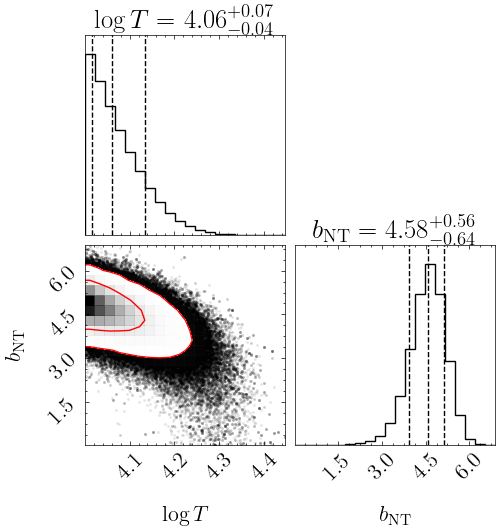

In [105]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [106]:
pdf, edges = np.histogram(flat_samples['logT'], bins=100)
centers = .5*(edges[1:]+edges[:-1])
cdf = np.cumsum(pdf)/np.sum(pdf)
ppf = interpolate.interp1d(x=cdf, y=10**centers)

Text(0, 0.5, 'CDF')

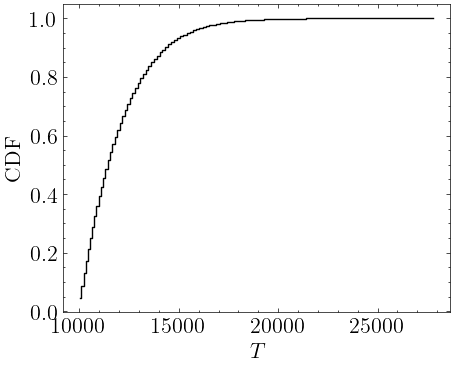

In [107]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.step(10**centers, cdf, where='mid')
ax.set_xlabel(r'$T$')
ax.set_ylabel('CDF')

In [108]:
np.log10(ppf(cdf_3sig))

4.3214786647846894

Predicted linewidths

In [109]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['He']))

8.372524072948604

In [110]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

6.112656325458805

In [111]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

5.916341425896229

In [112]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

5.7657767681406344

In [113]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

5.538853280365325

In [114]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

5.386843445584526

In [115]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

5.31143448033901

In [116]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

5.2844805211879375

In [117]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

5.201714607354935

In [118]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

4.944810939742383

# z=1.04, c3

In [119]:
b_list = [[['HI', 'H', 13, 3],
          ['CIV', 'C', 10, 1]]]

In [120]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [121]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [122]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:09<00:00, 500.07it/s]


State([[ 4.23218762  4.11055403]
 [ 4.01096603  9.81387467]
 [ 4.32014129  5.82682142]
 [ 4.41083246  6.12907601]
 [ 4.05571888  9.79547803]
 [ 4.07775203 10.90877397]
 [ 4.13266118  8.69357491]
 [ 4.04348583  9.27144635]
 [ 4.02701482  8.67683939]
 [ 4.30439777  9.61060166]
 [ 4.04661843  8.38007869]
 [ 4.28662148  6.49285071]
 [ 4.0469869   9.69431385]
 [ 4.14912211  6.04975955]
 [ 4.13556474  7.66106447]
 [ 4.08997358  9.25792715]
 [ 4.02185712 10.56920303]
 [ 4.16404912  7.58786401]
 [ 4.16617506  9.40753453]
 [ 4.32504446  6.86633046]
 [ 4.17039836  6.89609304]
 [ 4.03746457  8.76376755]
 [ 4.30561803  6.31551914]
 [ 4.03430512  8.65927821]
 [ 4.25301708  9.37250702]
 [ 4.19144244  8.20392265]
 [ 4.21763463  8.3198615 ]
 [ 4.01338698  8.52399937]
 [ 4.03006236  9.3300845 ]
 [ 4.4228354   8.18992679]
 [ 4.01292679  7.71220772]
 [ 4.0534092   8.71004934]
 [ 4.25709647  9.21694853]
 [ 4.16733662  9.16212491]
 [ 4.22061801  7.06159366]
 [ 4.08660486  8.70668643]
 [ 4.09356505  9.13532

In [123]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

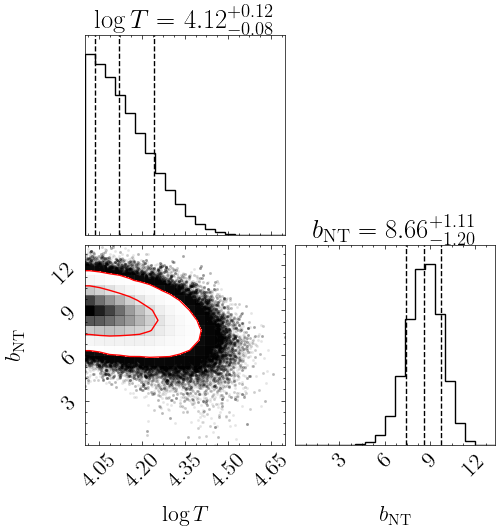

In [124]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [125]:
pdf, edges = np.histogram(flat_samples['logT'], bins=100)
centers = .5*(edges[1:]+edges[:-1])
cdf = np.cumsum(pdf)/np.sum(pdf)
ppf = interpolate.interp1d(x=cdf, y=10**centers)

Text(0, 0.5, 'CDF')

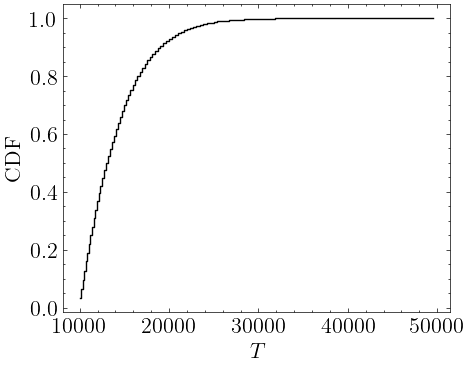

In [126]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.step(10**centers, cdf, where='mid')
ax.set_xlabel(r'$T$')
ax.set_ylabel('CDF')

In [127]:
np.log10(ppf(cdf_3sig))

4.495447744891298

Predicted linewidths

In [128]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['He']))

11.545333273557603

In [129]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

9.712277083470118

In [130]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

9.567463191024636

In [131]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

9.457991462675661

In [132]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

9.296541308741944

In [133]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

9.191014048322153

In [134]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

9.139070139537838

In [135]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

9.120469849060417

In [136]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

9.064251913950796

In [137]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

8.892762258405323

# z=1.04, c4

In [138]:
b_list = [[['HI', 'H', 21, 6],
          ['CIV', 'C', 8.2, 0.6]]]

In [140]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [141]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [142]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:09<00:00, 514.57it/s]


State([[4.50333294 2.64154217]
 [4.45165987 5.6776955 ]
 [4.74317716 2.3513273 ]
 [4.59021108 0.25265008]
 [4.49264524 4.94590987]
 [4.58446068 1.75182805]
 [4.34115602 5.42352542]
 [4.47325828 5.331459  ]
 [4.68861362 0.28790426]
 [4.48729767 4.01116099]
 [4.68909865 2.52727793]
 [4.30927953 6.96417115]
 [4.70999316 1.67464491]
 [4.51748226 5.17634411]
 [4.63135362 3.77243103]
 [4.51838281 5.48370884]
 [4.24632537 6.01321487]
 [4.44001139 6.19015669]
 [4.37144956 6.21475396]
 [4.6226641  5.20646169]
 [4.64556628 2.13108867]
 [4.70471123 1.66986187]
 [4.34077136 6.75991058]
 [4.30936529 4.62164959]
 [4.19761707 6.28313796]
 [4.62631406 3.12314591]
 [4.42647064 3.42832814]
 [4.56424826 4.74312937]
 [4.16168383 6.95862597]
 [4.32181014 6.50668948]
 [4.61725516 4.30498326]
 [4.64575942 3.14726627]
 [4.50757129 1.95443485]
 [4.0653724  7.63269398]
 [4.6098073  3.27855165]
 [4.38143992 6.23853328]
 [4.56294277 3.06779156]
 [4.57098615 4.08149712]
 [4.40097544 5.17551636]
 [4.64257639 3.6400

In [145]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

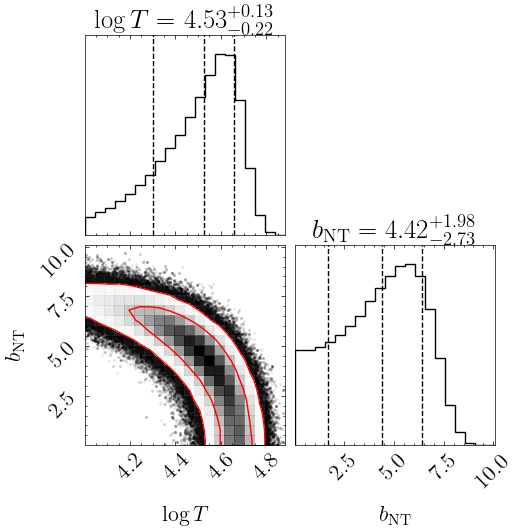

In [146]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [147]:
pdf, edges = np.histogram(flat_samples['logT'], bins=100)
centers = .5*(edges[1:]+edges[:-1])
cdf = np.cumsum(pdf)/np.sum(pdf)
ppf = interpolate.interp1d(x=cdf, y=10**centers)

Text(0, 0.5, 'CDF')

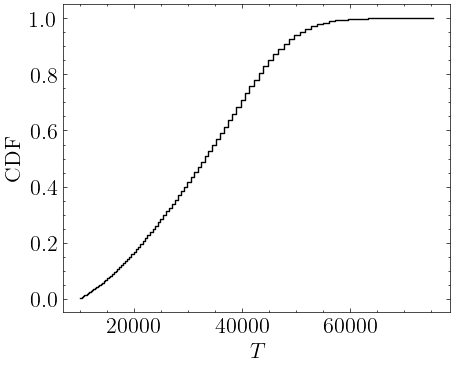

In [148]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.step(10**centers, cdf, where='mid')
ax.set_xlabel(r'$T$')
ax.set_ylabel('CDF')

In [149]:
np.log10(ppf(cdf_3sig))

4.800429413069587

In [150]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

8.559673685556994

Predicted linewidths

In [151]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['He']))

12.592727588797956

In [152]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

8.20809891625722

In [153]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

7.7890323356260565

In [154]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

7.453494163003777

In [155]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

6.923633499823852

In [156]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

6.555497785107799

In [157]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

6.369975312992784

In [158]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

6.302751162753574

In [159]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

6.09733601442623

In [160]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

5.442249000714465

# z=1.09

In [126]:
b_list = [[['HI', 'H', 23, 3],
          ['CIV', 'C', 18.2, 0.3],
          ['NIV', 'N', 13, 7],
          ['OIII', 'O', 25, 2],
          ['OIV', 'O', 23, 1],
          ['OV', 'O', 26, 2]]]

In [127]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [128]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [129]:
sampler.run_mcmc(pos, 500, progress=True)

100%|████████████████████████████████████████| 500/500 [00:04<00:00, 120.66it/s]


State([[ 4.00117079 18.21549755]
 [ 4.05911967 18.40625978]
 [ 4.08247792 18.53538709]
 [ 4.0494092  18.38707684]
 [ 4.12833651 18.12965565]
 [ 4.33063341 18.28392667]
 [ 4.18573355 18.39048939]
 [ 4.13362469 18.36871919]
 [ 4.04105009 18.51576285]
 [ 4.08297248 18.39291235]
 [ 4.09104843 19.00429223]
 [ 4.1547625  18.161414  ]
 [ 4.0775782  18.17560762]
 [ 4.41263557 17.93993156]
 [ 4.2316961  17.86453226]
 [ 4.0356652  18.34606758]
 [ 4.05322987 19.04001842]
 [ 4.01951805 18.44885606]
 [ 4.12622807 18.11862563]
 [ 4.00064414 18.17082097]
 [ 4.19153583 18.80633722]
 [ 4.12006435 18.2620524 ]
 [ 4.04924453 18.4226305 ]
 [ 4.24799842 18.07015892]
 [ 4.04463896 18.54530239]
 [ 4.04231867 18.16178345]
 [ 4.18983821 17.57720656]
 [ 4.27155219 18.56329383]
 [ 4.01630526 18.57751686]
 [ 4.05449006 19.09136679]
 [ 4.00057667 18.34312095]
 [ 4.13725985 17.97369642]
 [ 4.08173057 18.68044598]
 [ 4.2349724  18.32286902]
 [ 4.01087578 18.52790545]
 [ 4.07910376 18.79794701]
 [ 4.07672061 18.06015

In [130]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logT', 'b_NT'])

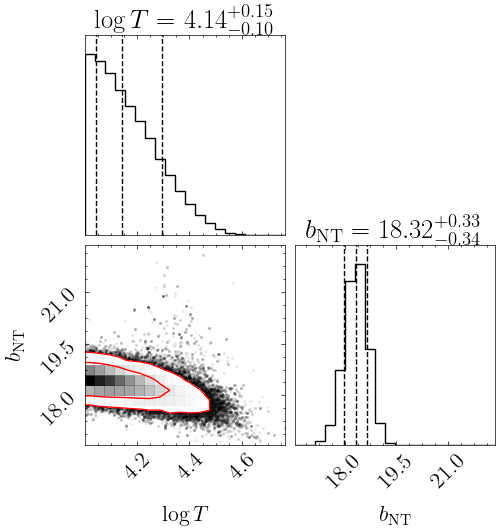

In [131]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [132]:
pdf, edges = np.histogram(flat_samples['logT'], bins=100)
centers = .5*(edges[1:]+edges[:-1])
cdf = np.cumsum(pdf)/np.sum(pdf)
ppf = interpolate.interp1d(x=cdf, y=10**centers)

Text(0, 0.5, 'CDF')

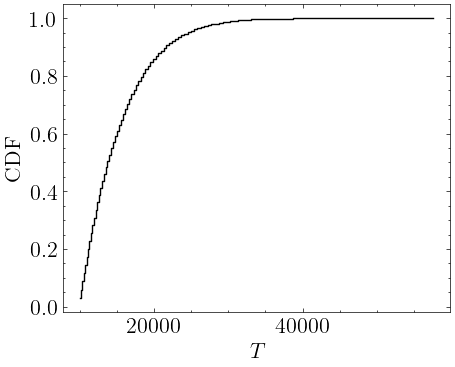

In [133]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.step(10**centers, cdf, where='mid')
ax.set_xlabel(r'$T$')
ax.set_ylabel('CDF')

In [134]:
np.log10(ppf(cdf_3sig))

4.573539932707806

Predicted linewidths

In [135]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['He']))

19.917864152148898

In [136]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

18.876339041594377

In [137]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

18.79707916017271

In [138]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

18.737842728457515

In [139]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

18.650809632299854

In [140]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

18.5943542256674

In [141]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

18.567154477500285

In [142]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

18.557542107629658

In [143]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

18.527823737101627

In [144]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

18.439417055644146

# z=1.16, c1

In [193]:
b_list = [[['HI', 'H', 21.4, 0.9],
          ['HeI', 'He', 14, 1],
          ['CIV', 'C', 11.0, 0.4],
          ['OIII', 'O', 16, 3],
          ['OIV', 'O', 18, 2],
          ['OV', 'O', 11, 3]]]

In [194]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [195]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [196]:
sampler.run_mcmc(pos, 500, progress=True)

100%|████████████████████████████████████████| 500/500 [00:04<00:00, 113.86it/s]


State([[ 4.27283803 10.49856558]
 [ 4.27590882 10.02413347]
 [ 4.31223796 10.04624617]
 [ 4.2739612  10.49141046]
 [ 4.32190215 10.63068726]
 [ 4.2315373  10.39309417]
 [ 4.38421548  9.54241494]
 [ 4.32948611 10.28326856]
 [ 4.24174145 10.0119109 ]
 [ 4.34639447 10.06948669]
 [ 4.30163325 11.0093111 ]
 [ 4.29354105 11.23799004]
 [ 4.34488802  9.9628231 ]
 [ 4.39383479 10.1122688 ]
 [ 4.31742277 10.67688314]
 [ 4.39136027  9.13289876]
 [ 4.37093034  9.5720733 ]
 [ 4.32598095  8.92361479]
 [ 4.40237189  9.85523074]
 [ 4.3570349  10.41210225]
 [ 4.26522138 10.54061609]
 [ 4.34195118 10.4078558 ]
 [ 4.38202974  9.90855349]
 [ 4.24894149  9.78496003]
 [ 4.39642401  9.56093089]
 [ 4.31501381  9.2279391 ]
 [ 4.36349916  9.29783859]
 [ 4.34950231  9.64346322]
 [ 4.34340187 10.18935466]
 [ 4.35811751 10.23871649]
 [ 4.29146326  9.96303896]
 [ 4.32311514  9.72333821]
 [ 4.34234258  9.90080069]
 [ 4.22458678 10.14882499]
 [ 4.43875401  9.1206423 ]
 [ 4.40851176  9.28380645]
 [ 4.4476934   8.97935

In [197]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logT', 'b_NT'])

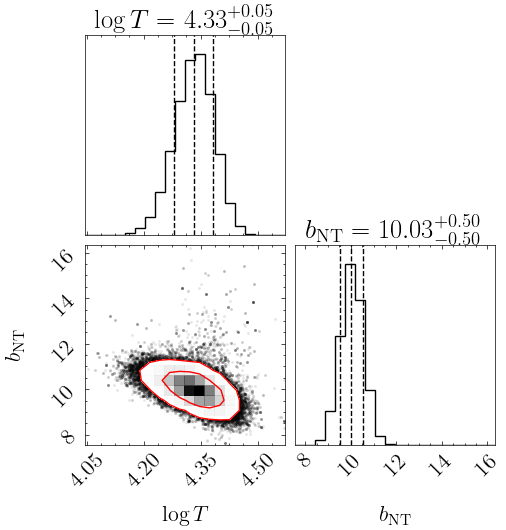

In [198]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [199]:
pdf, edges = np.histogram(flat_samples['logT'], bins=100)
centers = .5*(edges[1:]+edges[:-1])
cdf = np.cumsum(pdf)/np.sum(pdf)
ppf = interpolate.interp1d(x=cdf, y=10**centers)

Text(0, 0.5, 'CDF')

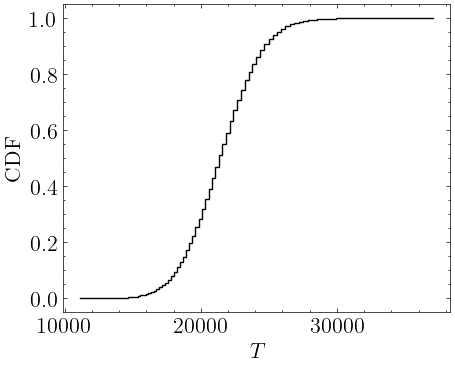

In [200]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.step(10**centers, cdf, where='mid')
ax.set_xlabel(r'$T$')
ax.set_ylabel('CDF')

In [201]:
np.log10(ppf(cdf_3sig))

4.473433924076069

Predicted linewidths

In [202]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['He']))

13.785412641247756

In [203]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

11.417986047199012

In [204]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

11.229742247231068

In [205]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

11.087127272228535

In [206]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

10.876522947961215

In [207]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

10.737382454898903

In [208]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

10.669627383387244

In [209]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

10.645108211219714

In [210]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

10.570570781238771

In [211]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

10.343286482271015

# z=1.16, c2

In [212]:
b_list = [[['HI', 'H', 33, 3],
          ['CIV', 'C', 26, 3],
          ['OIV', 'O', 28, 12],
          ['OV', 'O', 27, 3]]]
          #['OVI', 'O', 45, 22]]]

In [213]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [214]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [215]:
sampler.run_mcmc(pos, 500, progress=True)

100%|████████████████████████████████████████| 500/500 [00:03<00:00, 154.54it/s]


State([[ 4.5961837  23.26529927]
 [ 4.14382645 28.88341105]
 [ 4.65141545 25.08064445]
 [ 4.19706648 28.28416547]
 [ 4.57957037 24.17964454]
 [ 4.49700144 23.89346242]
 [ 4.47224483 27.02280788]
 [ 4.56722202 24.80637331]
 [ 4.124536   27.06655262]
 [ 4.44886993 27.96487141]
 [ 4.16276719 26.43553432]
 [ 4.40157785 24.89829354]
 [ 4.24467895 25.24547705]
 [ 4.45302097 29.17030071]
 [ 4.42422079 25.07032743]
 [ 4.55129236 26.27996708]
 [ 4.84014459 23.2901084 ]
 [ 4.59310734 23.75749802]
 [ 4.41213694 28.79572612]
 [ 4.22401139 26.5322434 ]
 [ 4.46348695 26.75492256]
 [ 4.20487748 24.43497588]
 [ 4.48712705 25.97821386]
 [ 4.43026739 25.12344562]
 [ 4.32459943 25.90512084]
 [ 4.5001497  28.67769043]
 [ 4.28224761 23.57117561]
 [ 4.35521022 26.0515472 ]
 [ 4.01437334 27.16879036]
 [ 4.26879135 24.43973641]
 [ 4.46461735 27.52718501]
 [ 4.36839702 23.27569245]
 [ 4.13411775 25.77382711]
 [ 4.40164564 27.10230623]
 [ 4.50379966 24.67085396]
 [ 4.04208362 28.03914159]
 [ 4.45175815 24.37670

In [216]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logT', 'b_NT'])

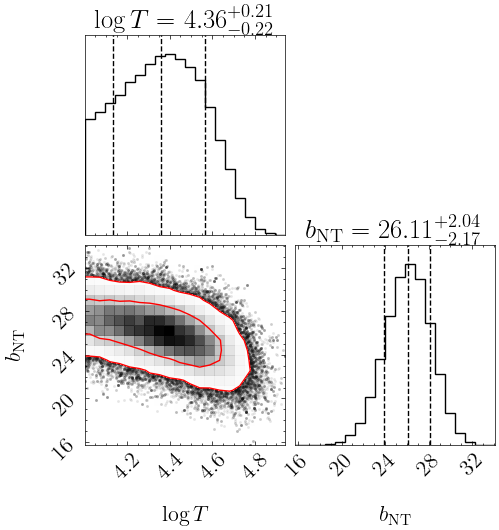

In [217]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [218]:
pdf, edges = np.histogram(flat_samples['logT'], bins=100)
centers = .5*(edges[1:]+edges[:-1])
cdf = np.cumsum(pdf)/np.sum(pdf)
ppf = interpolate.interp1d(x=cdf, y=10**centers)

Text(0, 0.5, 'CDF')

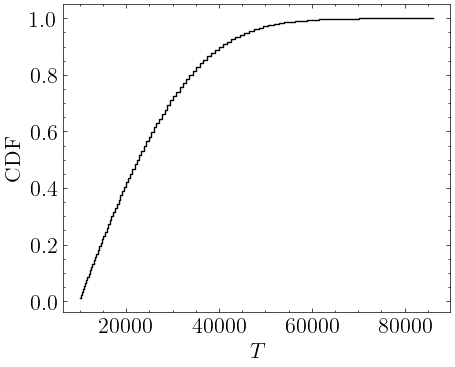

In [219]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.step(10**centers, cdf, where='mid')
ax.set_xlabel(r'$T$')
ax.set_ylabel('CDF')

In [220]:
np.log10(ppf(cdf_3sig))

4.83537328287398

Predicted linewidths

In [221]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['He']))

27.980415852496815

In [222]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

26.725842917664302

In [223]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

26.6367723162639

In [224]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

26.57092797253792

In [231]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

26.472509602505554

In [232]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

26.41046373303604

In [233]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

26.380916383201907

In [234]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

26.370391364213777

In [235]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

26.338393760907397

In [236]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

26.239534349231665

# z=1.27, c1

In [237]:
b_list = [[['HI', 'H', 24, 3],
          ['CIII', 'C', 20, 12],
          ['CIV', 'C', 11.1, 0.2],
          ['NIV', 'N', 10, 6],
          ['OIII', 'O', 18, 6],
          ['OIV', 'O', 12, 1]]]

In [238]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [239]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [240]:
sampler.run_mcmc(pos, 500, progress=True)

100%|████████████████████████████████████████| 500/500 [00:04<00:00, 117.05it/s]


State([[ 4.57455996  8.22865397]
 [ 4.34523257 10.09254351]
 [ 4.78454789  5.63988263]
 [ 4.57641347  8.81268089]
 [ 4.4754388   9.05312848]
 [ 4.42605998  9.46842059]
 [ 4.44940776  9.44039319]
 [ 4.56108079  8.77161741]
 [ 4.47741133  9.24269112]
 [ 4.27770795  9.73626156]
 [ 4.50258189  9.20074702]
 [ 4.50729486  8.8923565 ]
 [ 4.60795267  8.54853134]
 [ 4.40674982  9.28592316]
 [ 4.35791386 10.09972055]
 [ 4.26448989 10.05359883]
 [ 4.47978466  8.82749804]
 [ 4.58156297  8.56897525]
 [ 4.61324833  7.64756267]
 [ 4.38298192  9.26891444]
 [ 4.37304331  9.97015077]
 [ 4.41258251  9.46524547]
 [ 4.28995862  9.70442227]
 [ 4.48277117  9.08716661]
 [ 4.39156196  9.30917162]
 [ 4.04051393 10.47603294]
 [ 4.27260457 10.05987028]
 [ 4.45159394  8.90285999]
 [ 4.33083557  9.48058061]
 [ 4.26713941  9.7870001 ]
 [ 4.45527743  9.33855595]
 [ 4.26855953  9.97992996]
 [ 4.51053363  9.13498361]
 [ 4.35953501  9.81521921]
 [ 4.19605851 10.35021807]
 [ 4.52541501  9.01557371]
 [ 4.51130981  8.99003

In [241]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logT', 'b_NT'])

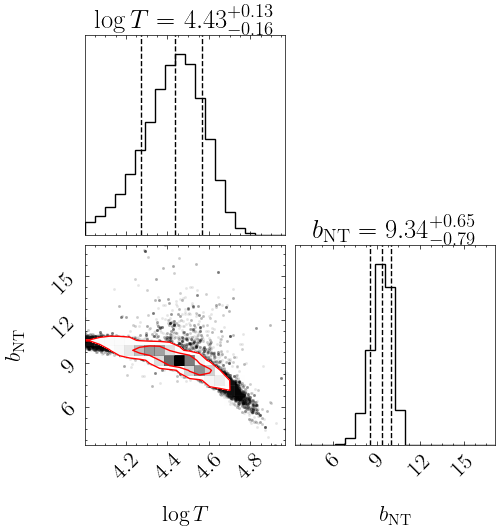

In [242]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Predicted linewidths

In [243]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['He']))

14.150084423037882

In [244]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

11.168928153371432

In [245]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

10.922722059003792

In [246]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

10.738001294328576

In [247]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

10.46289546474133

In [248]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

10.280530734619074

In [249]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

10.190362211032772

In [250]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

10.158320830662094

In [251]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

10.059627303561133

In [252]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

9.757582585849942

# z=1.27, c2

In [253]:
b_list = [[['HI', 'H', 37, 10],
          ['CIV', 'C', 9.8, 0.3],
          ['OIV', 'O', 11, 2]]]

In [254]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [255]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [256]:
sampler.run_mcmc(pos, 500, progress=True)

100%|████████████████████████████████████████| 500/500 [00:02<00:00, 195.07it/s]


State([[4.91730062 1.22333723]
 [4.79782432 3.02872209]
 [4.21350986 9.14835859]
 [4.55692966 6.77901938]
 [4.58103069 7.58522909]
 [4.69051508 4.70994601]
 [4.82051604 1.97848308]
 [4.0523094  8.70169116]
 [4.50583188 7.21608833]
 [4.6397898  6.35974467]
 [4.76394866 3.1550962 ]
 [4.75952245 4.18190921]
 [4.42553914 7.76221219]
 [4.81877805 3.32084128]
 [4.65538499 6.08334845]
 [4.59254902 7.32893312]
 [4.15817929 8.59203846]
 [4.77485173 3.61911997]
 [4.81177767 3.77077299]
 [4.69844783 4.93791   ]
 [4.60002508 6.91132753]
 [4.75251959 4.83914457]
 [4.72868104 4.42122966]
 [4.04691416 8.88448068]
 [4.42944575 8.07758165]
 [4.79381438 1.41627862]
 [4.9054507  2.05365683]
 [4.42533845 7.95478618]
 [4.54011988 6.9881505 ]
 [4.32747344 8.17115526]
 [4.85344867 1.83394762]
 [4.07060217 8.68331041]
 [4.85530713 2.34745695]
 [4.83755554 0.07926533]
 [4.72669462 4.37437451]
 [4.79492433 3.54140046]
 [4.84554548 0.16973693]
 [4.07815528 9.82111947]
 [4.80560856 3.67494889]
 [4.85148409 2.1028

In [257]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logT', 'b_NT'])

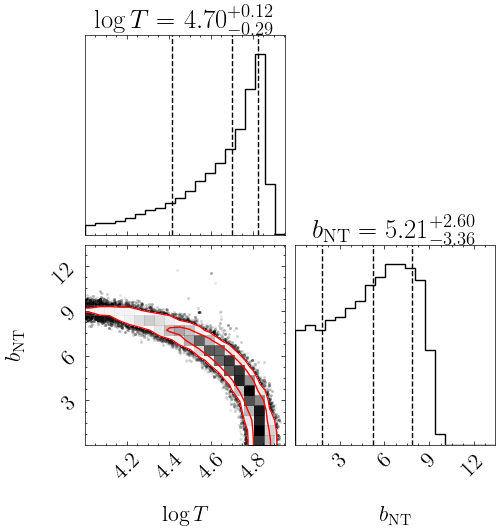

In [258]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [259]:
pdf, edges = np.histogram(flat_samples['logT'], bins=100)
centers = .5*(edges[1:]+edges[:-1])
cdf = np.cumsum(pdf)/np.sum(pdf)
ppf = interpolate.interp1d(x=cdf, y=10**centers)

Text(0, 0.5, 'CDF')

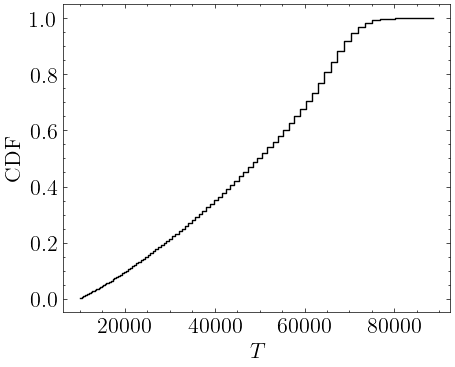

In [260]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.step(10**centers, cdf, where='mid')
ax.set_xlabel(r'$T$')
ax.set_ylabel('CDF')

In [261]:
np.log10(ppf(cdf_3sig))

4.898302676483233

In [262]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

9.641051233823294

Predicted linewidths

In [263]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['He']))

15.37724357091142

In [264]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

9.86713896817735

In [265]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

9.365977482886219

In [266]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

8.95315712573851

In [268]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

8.304435989563137

In [269]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

7.863795747292576

In [270]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

7.641438916316469

In [274]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

7.561106632815019

In [275]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

7.309949779597184

In [276]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

6.49720994737811